<a href="https://colab.research.google.com/github/Ms-Ulfiyahrustam/Prediction_Apple_Share/blob/main/Prediksi_Harga_Closing_Saham_Apple.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##**Deskripsi**

Pada projek ini, kami melakukan analisis histori harga saham Apple berdasarkan rekam jejak transaksi saham harian dari perusahaan teknologi Apple Inc.

##**Tujuan**

Tujuan dari projek ini adalah mengetahui harga closing dari saham Apple Inc.

## **Library**
Pandas - Baca CSV atau dataset

Matplotlib.pyplot & Seaborn - Visualisasi saham

Numpy - Perhitungan untuk prediksi

In [125]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import sklearn
from sklearn.model_selection import train_test_split, TimeSeriesSplit
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
)
from sklearn.preprocessing import StandardScaler

## Load data

In [126]:
df = pd.read_csv('Apple.csv')
df.head()

,Date,Open,High,Low,Close,Adj Close,Volume
0,2015-01-02,27.847500,27.860001,26.837500,27.332500,24.745996,212818400
1,2015-01-05,27.072500,27.162500,26.352501,26.562500,24.048864,257142000
2,2015-01-06,26.635000,26.857500,26.157499,26.565001,24.051125,263188400
3,2015-01-07,26.799999,27.049999,26.674999,26.937500,24.388372,160423600
4,2015-01-08,27.307501,28.037500,27.174999,27.972500,25.325430,237458000


In [127]:
df["Date"] = pd.to_datetime(df["Date"])
df = df.sort_values("Date").reset_index(drop=True)

In [128]:
print("=== INFO DATASET ===")
print(df.info())

=== INFO DATASET ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1761 entries, 0 to 1760
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   Date       1761 non-null   datetime64[ns]
 1   Open       1761 non-null   float64       
 2   High       1761 non-null   float64       
 3   Low        1761 non-null   float64       
 4   Close      1761 non-null   float64       
 5   Adj Close  1761 non-null   float64       
 6   Volume     1761 non-null   int64         
dtypes: datetime64[ns](1), float64(5), int64(1)
memory usage: 96.4 KB
None


In [129]:
df.head(5 )

,Date,Open,High,Low,Close,Adj Close,Volume
0,2015-01-02,27.847500,27.860001,26.837500,27.332500,24.745996,212818400
1,2015-01-05,27.072500,27.162500,26.352501,26.562500,24.048864,257142000
2,2015-01-06,26.635000,26.857500,26.157499,26.565001,24.051125,263188400
3,2015-01-07,26.799999,27.049999,26.674999,26.937500,24.388372,160423600
4,2015-01-08,27.307501,28.037500,27.174999,27.972500,25.325430,237458000


In [130]:
print(f"\nRentang data: {df['Date'].min().date()} → {df['Date'].max().date()}")
print(f"Total baris : {len(df)}")


Rentang data: 2015-01-02 → 2021-12-29
Total baris : 1761


## EDA

### Cleaning data


In [131]:
print("\n=== CEK MISSING VALUE ===")
print(df.isnull().sum())


=== CEK MISSING VALUE ===
Date         0
Open         0
High         0
Low          0
Close        0
Adj Close    0
Volume       0
dtype: int64


In [132]:
print("\n=== CEK DUPLIKAT ===")
print(f"Jumlah duplikat: {df.duplicated().sum()}")


=== CEK DUPLIKAT ===
Jumlah duplikat: 0


### explore data ->  with visualition

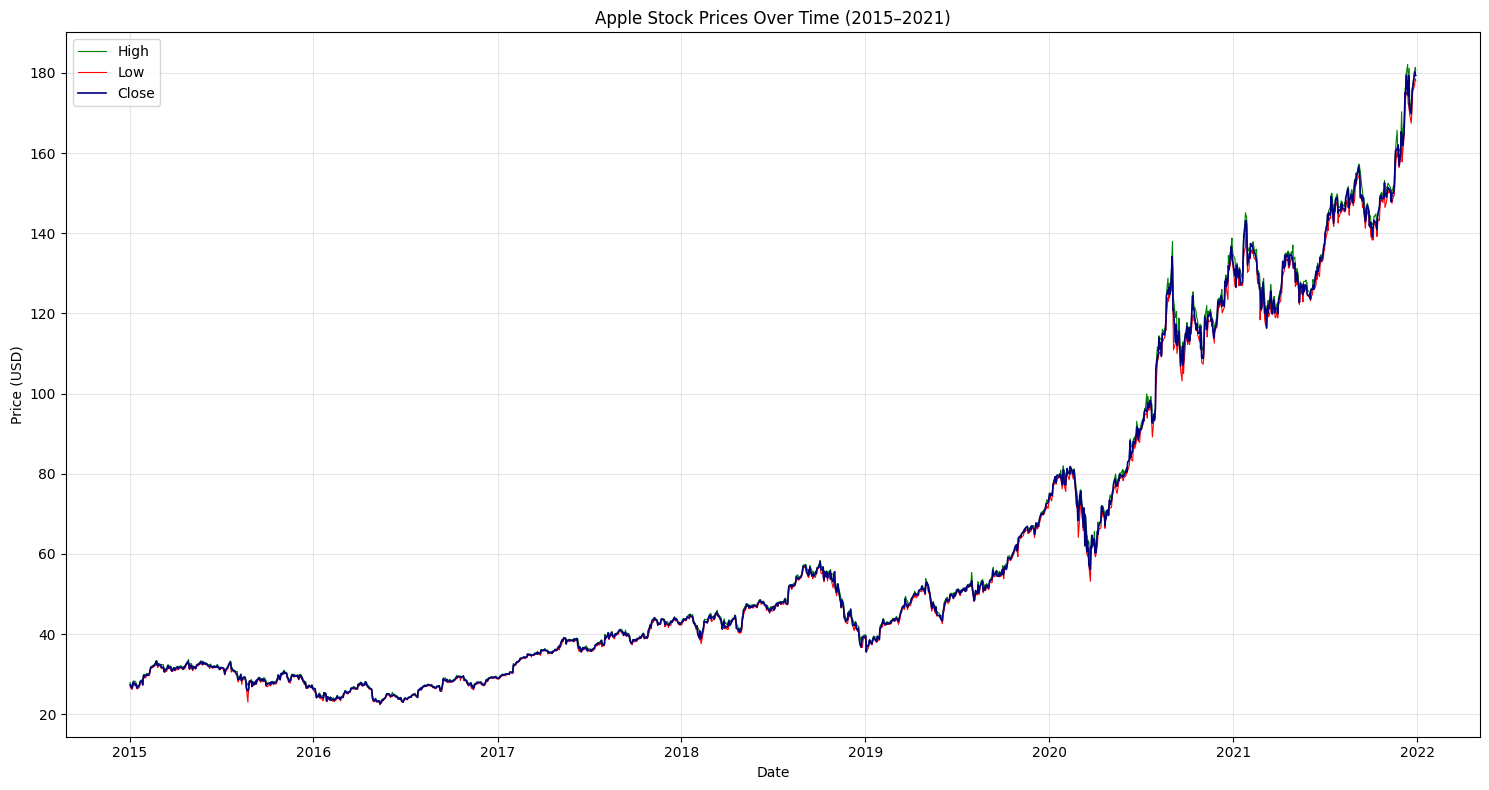

In [133]:
# Visualisasi harga historis
plt.figure(figsize=(15, 8))
plt.plot(df["Date"], df["High"],  label="High",  color="green",  linewidth=0.8)
plt.plot(df["Date"], df["Low"],   label="Low",   color="red",    linewidth=0.8)
plt.plot(df["Date"], df["Close"], label="Close", color="navy",   linewidth=1.2)
plt.title("Apple Stock Prices Over Time (2015–2021)")
plt.xlabel("Date")
plt.ylabel("Price (USD)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("01_harga_historis.png", dpi=150)
plt.show()

Heatmap korelasi (sebelum feature engineering)


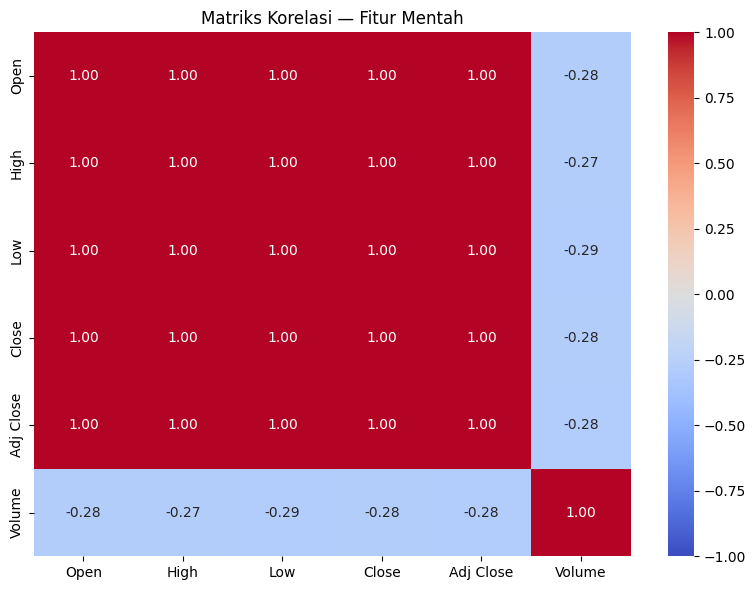

In [134]:
print("Heatmap korelasi (sebelum feature engineering)")
plt.figure(figsize=(8, 6))
numeric_cols = ["Open", "High", "Low", "Close", "Adj Close", "Volume"]
sns.heatmap(
    df[numeric_cols].corr(),
    annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1,
)
plt.title("Matriks Korelasi — Fitur Mentah")
plt.tight_layout()
plt.savefig("02_korelasi_mentah.png", dpi=150)
plt.show()

## Feature Enginering

In [135]:
# --- Moving Average ---
df["MA_5"]  = df["Close"].rolling(window=5,  min_periods=1).mean()
df["MA_20"] = df["Close"].rolling(window=20, min_periods=1).mean()
df["MA_50"] = df["Close"].rolling(window=50, min_periods=1).mean()

In [136]:
# --- Price Spread & Candlestick Body ---
df["daily_range"]    = df["High"] - df["Low"]           # Volatilitas hari ini
df["body"]           = df["Close"] - df["Open"]         # Arah pergerakan
df["upper_shadow"]   = df["High"] - df[["Open","Close"]].max(axis=1)
df["lower_shadow"]   = df[["Open","Close"]].min(axis=1) - df["Low"]

In [137]:
# --- Momentum & Return ---
df["return_1d"] = df["Close"].pct_change(1)             # Return 1 hari
df["return_5d"] = df["Close"].pct_change(5)             # Return 5 hari
df["momentum"]  = df["Close"] - df["Close"].shift(10)   # Momentum 10 hari

In [138]:
# --- Volatilitas Rolling ---
df["volatility_10"] = df["Close"].rolling(10).std()
df["volatility_20"] = df["Close"].rolling(20).std()

In [139]:
# --- Volume Change ---
df["volume_change"] = df["Volume"].pct_change()
df["vol_MA_5"]      = df["Volume"].rolling(5).mean()

In [140]:
# --- Cyclical Encoding Bulan (sin/cos, lebih baik dari nama bulan) ---
df["month_sin"] = np.sin(2 * np.pi * df["Date"].dt.month / 12)
df["month_cos"] = np.cos(2 * np.pi * df["Date"].dt.month / 12)

In [141]:
# --- Hari dalam Seminggu ---
df["weekday_sin"] = np.sin(2 * np.pi * df["Date"].dt.dayofweek / 5)
df["weekday_cos"] = np.cos(2 * np.pi * df["Date"].dt.dayofweek / 5)

In [142]:
# --- MACD (Moving Average Convergence Divergence) ---
ema12 = df["Close"].ewm(span=12, adjust=False).mean()
ema26 = df["Close"].ewm(span=26, adjust=False).mean()
df["MACD"]        = ema12 - ema26
df["MACD_signal"] = df["MACD"].ewm(span=9, adjust=False).mean()

In [143]:
# --- RSI (Relative Strength Index) ---
def compute_rsi(series, period=14):
    delta = series.diff()
    gain  = delta.clip(lower=0).rolling(window=period).mean()
    loss  = (-delta.clip(upper=0)).rolling(window=period).mean()
    rs    = gain / (loss + 1e-10)
    return 100 - (100 / (1 + rs))

df["RSI"] = compute_rsi(df["Close"], period=14)

In [144]:
# --- Bollinger Band Width ---
bb_mid   = df["Close"].rolling(20).mean()
bb_std   = df["Close"].rolling(20).std()
df["BB_upper"] = bb_mid + 2 * bb_std
df["BB_lower"] = bb_mid - 2 * bb_std
df["BB_width"] = (df["BB_upper"] - df["BB_lower"]) / bb_mid  # Normalized width

In [145]:
# --- TARGET: Harga closing hari berikutnya ---
df["Target"] = df["Close"].shift(-1)
print(df.tail())

           Date        Open        High         Low       Close   Adj Close  \
1756 2021-12-22  173.039993  175.860001  172.149994  175.639999  175.639999   
1757 2021-12-23  175.850006  176.850006  175.270004  176.279999  176.279999   
1758 2021-12-27  177.089996  180.419998  177.070007  180.330002  180.330002   
1759 2021-12-28  180.160004  181.330002  178.529999  179.289993  179.289993   
1760 2021-12-29  179.330002  180.630005  178.139999  179.380005  179.380005   

        Volume        MA_5     MA_20       MA_50  ...  month_cos  weekday_sin  \
1756  92135300  172.356000  169.5700  158.158201  ...        1.0     0.587785   
1757  68227500  173.160000  170.2870  158.865601  ...        1.0    -0.587785   
1758  74919600  174.998001  171.4630  159.597001  ...        1.0     0.000000   
1759  79144300  176.906000  172.4155  160.286001  ...        1.0     0.951057   
1760  62231200  178.184000  173.1195  160.942601  ...        1.0     0.587785   

      weekday_cos      MACD  MACD_sign

In [146]:
FEATURE_COLS = [
    "MA_5", "MA_20", "MA_50",
    "daily_range", "body", "upper_shadow", "lower_shadow",
    "return_1d", "return_5d", "momentum",
    "volatility_10", "volatility_20",
    "volume_change", "vol_MA_5",
    "month_sin", "month_cos",
    "weekday_sin", "weekday_cos",
    "MACD", "MACD_signal",
    "RSI",
    "BB_width",
]

print(f"\nTotal fitur yang digunakan: {len(FEATURE_COLS)}")
print(FEATURE_COLS)


Total fitur yang digunakan: 22
['MA_5', 'MA_20', 'MA_50', 'daily_range', 'body', 'upper_shadow', 'lower_shadow', 'return_1d', 'return_5d', 'momentum', 'volatility_10', 'volatility_20', 'volume_change', 'vol_MA_5', 'month_sin', 'month_cos', 'weekday_sin', 'weekday_cos', 'MACD', 'MACD_signal', 'RSI', 'BB_width']


In [147]:
# Hapus baris dengan NaN (hasil rolling/shift)
df_model = df[FEATURE_COLS + ["Target", "Date"]].dropna().copy()
print(f"\nJumlah baris setelah dropna: {len(df_model)}")


Jumlah baris setelah dropna: 1741


In [148]:
X = df_model[FEATURE_COLS].values
y = df_model["Target"].values
dates = df_model["Date"].values

## Splitting -

In [149]:
split_idx = int(len(df_model) * 0.80)

X_train, X_test = X[:split_idx], X[split_idx:]
y_train, y_test = y[:split_idx], y[split_idx:]
dates_train = dates[:split_idx]
dates_test  = dates[split_idx:]

print(f"\n=== SPLIT TEMPORAL ===")
print(f"Train : {len(X_train)} baris  ({pd.Timestamp(dates_train[0]).date()} → {pd.Timestamp(dates_train[-1]).date()})")
print(f"Test  : {len(X_test)}  baris  ({pd.Timestamp(dates_test[0]).date()}  → {pd.Timestamp(dates_test[-1]).date()})")


=== SPLIT TEMPORAL ===
Train : 1392 baris  (2015-01-30 → 2020-08-10)
Test  : 349  baris  (2020-08-11  → 2021-12-28)


## Feature scalling

In [150]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)    # fit + transform di train
X_test_scaled  = scaler.transform(X_test)         # hanya transform di test

## trining model :


In [151]:
model = LinearRegression()
model.fit(X_train_scaled, y_train)

# Koefisien fitur
coef_df = (
    pd.DataFrame({"feature": FEATURE_COLS, "coefficient": model.coef_})
    .reindex(pd.Series(np.abs(model.coef_)).sort_values(ascending=False).index)
    .reset_index(drop=True)
)
print("\n=== KOEFISIEN MODEL (Top 10) ===")
print(coef_df.head(10).to_string(index=False))


=== KOEFISIEN MODEL (Top 10) ===
      feature  coefficient
        MA_20    24.847929
         MA_5   -13.137070
         MACD     8.980825
  MACD_signal    -5.774015
        MA_50     3.987382
volatility_20    -0.397681
    return_1d     0.215829
    return_5d     0.206012
     BB_width     0.181607
volatility_10     0.149501


## Prediksi dan evaluasi :

In [152]:
y_pred_train = model.predict(X_train_scaled)
y_pred_test  = model.predict(X_test_scaled)

def evaluate(y_true, y_pred, label):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / (y_true + 1e-10))) * 100
    print(f"\n=== EVALUASI — {label} ===")
    print(f"  MAE  : {mae:.4f}")
    print(f"  RMSE : {rmse:.4f}")
    print(f"  R²   : {r2:.4f}")
    print(f"  MAPE : {mape:.2f}%")
    return mae, rmse, r2, mape

mae_tr, rmse_tr, r2_tr, mape_tr = evaluate(y_train, y_pred_train, "TRAIN")
mae_te, rmse_te, r2_te, mape_te = evaluate(y_test,  y_pred_test,  "TEST")




=== EVALUASI — TRAIN ===
  MAE  : 0.5853
  RMSE : 0.9783
  R²   : 0.9967
  MAPE : 1.29%

=== EVALUASI — TEST ===
  MAE  : 2.0998
  RMSE : 2.7431
  R²   : 0.9703
  MAPE : 1.59%


In [153]:
# Deteksi overfitting sederhana
print("\n=== CEK OVERFITTING ===")
gap = r2_tr - r2_te
if gap > 0.10:
    print(f"⚠️  Gap R² = {gap:.4f} → indikasi overfitting (train jauh lebih baik dari test)")
else:
    print(f"✅  Gap R² = {gap:.4f} → model generalizes cukup baik")


=== CEK OVERFITTING ===
✅  Gap R² = 0.0265 → model generalizes cukup baik


## CROSS-VALIDATION — TimeSeriesSplit

In [156]:
from sklearn.model_selection import cross_val_score
tscv = TimeSeriesSplit(n_splits=5)

# CV pada data train saja (bukan seluruh dataset)
X_cv = X_train_scaled
y_cv = y_train

cv_mae  = cross_val_score(model, X_cv, y_cv, cv=tscv, scoring="neg_mean_absolute_error")
cv_rmse = cross_val_score(model, X_cv, y_cv, cv=tscv, scoring="neg_root_mean_squared_error")
cv_r2   = cross_val_score(model, X_cv, y_cv, cv=tscv, scoring="r2")

print("\n=== CROSS-VALIDATION (TimeSeriesSplit, k=5) ===")
print(f"  MAE  per fold : {(-cv_mae).round(4)}")
print(f"  MAE  rata-rata: {(-cv_mae).mean():.4f} \u00b1 {cv_mae.std():.4f}")
print(f"  RMSE rata-rata: {(-cv_rmse).mean():.4f} \u00b1 {cv_rmse.std():.4f}")
print(f"  R\u00b2   rata-rata: {cv_r2.mean():.4f}  \u00b1 {cv_r2.std():.4f}")


=== CROSS-VALIDATION (TimeSeriesSplit, k=5) ===
  MAE  per fold : [0.9259 0.3689 0.5453 0.8151 1.3729]
  MAE  rata-rata: 0.8056 ± 0.3449
  RMSE rata-rata: 1.1014 ± 0.5427
  R²   rata-rata: 0.9029  ± 0.1358


## Visualisasi

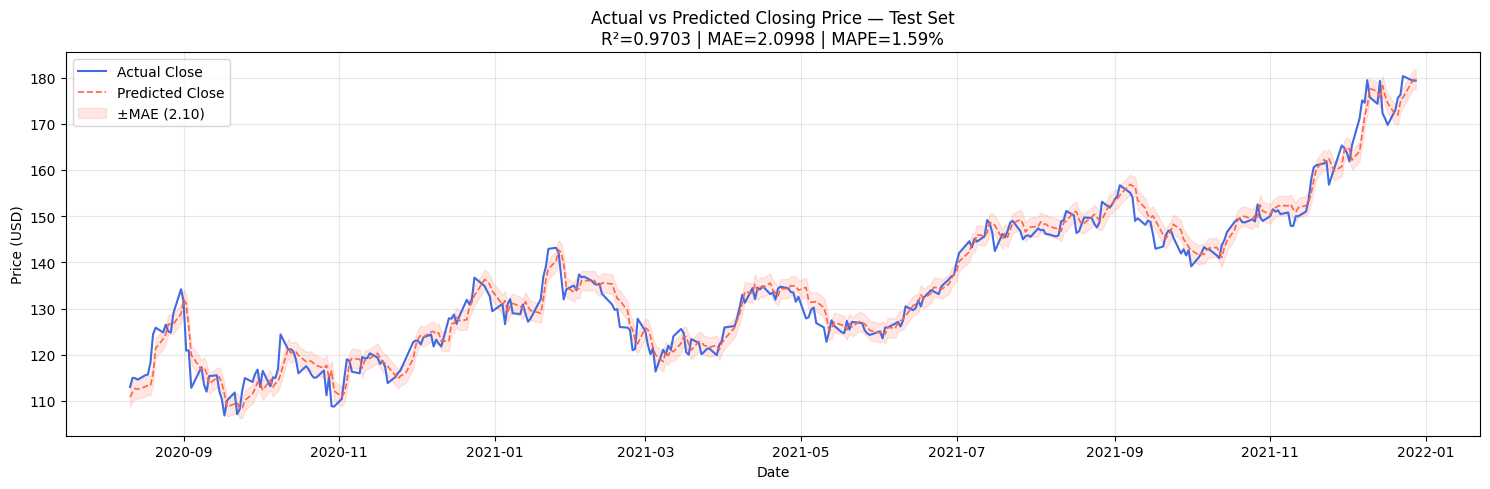

In [157]:
# ── 9.1  Actual vs Predicted (Test) ──────────
plt.figure(figsize=(15, 5))
plt.plot(dates_test, y_test,     label="Actual Close",    color="royalblue",  linewidth=1.5)
plt.plot(dates_test, y_pred_test, label="Predicted Close", color="tomato",
         linewidth=1.2, linestyle="--")
plt.fill_between(dates_test,
                 y_pred_test - mae_te,
                 y_pred_test + mae_te,
                 alpha=0.15, color="tomato", label=f"±MAE ({mae_te:.2f})")
plt.title(f"Actual vs Predicted Closing Price — Test Set\nR²={r2_te:.4f} | MAE={mae_te:.4f} | MAPE={mape_te:.2f}%")
plt.xlabel("Date")
plt.ylabel("Price (USD)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("03_actual_vs_predicted.png", dpi=150)
plt.show()

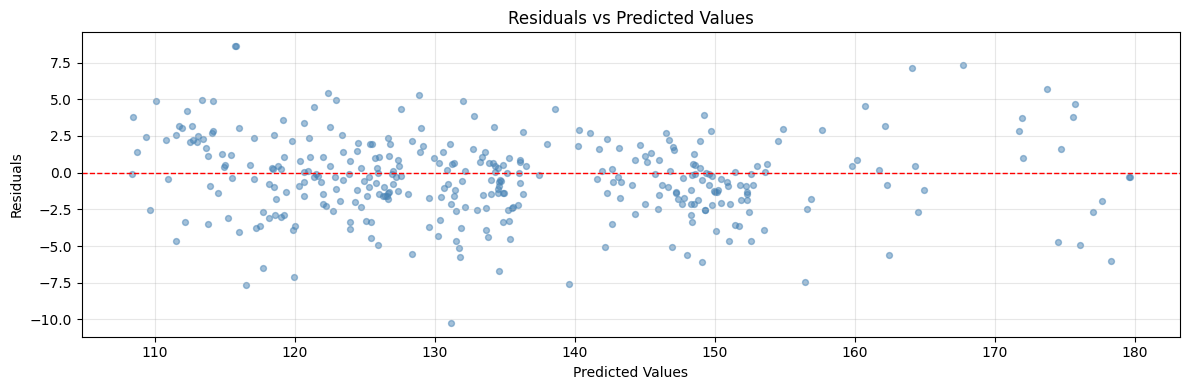

In [158]:
# ── 9.2  Residual Scatter ─────────────────────
residuals = y_test - y_pred_test
plt.figure(figsize=(12, 4))
plt.scatter(y_pred_test, residuals, alpha=0.5, s=18, color="steelblue")
plt.axhline(0, color="red", linestyle="--", linewidth=1)
plt.title("Residuals vs Predicted Values")
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("04_residual_scatter.png", dpi=150)
plt.show()

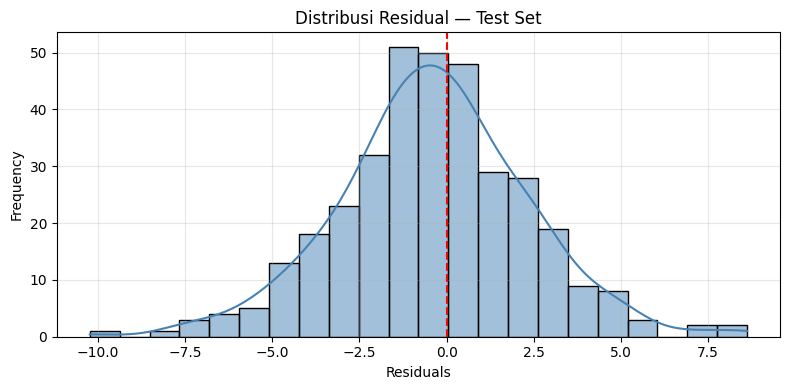

In [159]:
# ── 9.3  Distribusi Residual ──────────────────
plt.figure(figsize=(8, 4))
sns.histplot(residuals, kde=True, color="steelblue")
plt.axvline(0, color="red", linestyle="--")
plt.title("Distribusi Residual — Test Set")
plt.xlabel("Residuals")
plt.ylabel("Frequency")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("05_distribusi_residual.png", dpi=150)
plt.show()

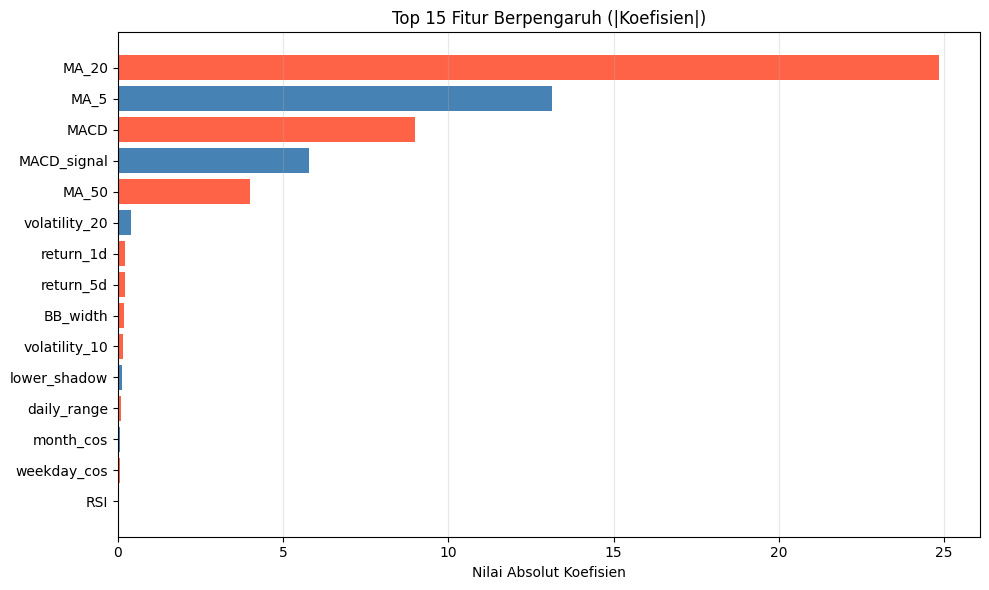

In [160]:
# ── 9.4  Feature Importance (Koefisien Absolut) ──
plt.figure(figsize=(10, 6))
top_n = 15
top_features = coef_df.head(top_n)
colors = ["tomato" if c > 0 else "steelblue" for c in top_features["coefficient"]]
plt.barh(top_features["feature"][::-1], top_features["coefficient"].abs()[::-1],
         color=colors[::-1])
plt.title(f"Top {top_n} Fitur Berpengaruh (|Koefisien|)")
plt.xlabel("Nilai Absolut Koefisien")
plt.grid(True, alpha=0.3, axis="x")
plt.tight_layout()
plt.savefig("06_feature_importance.png", dpi=150)
plt.show()

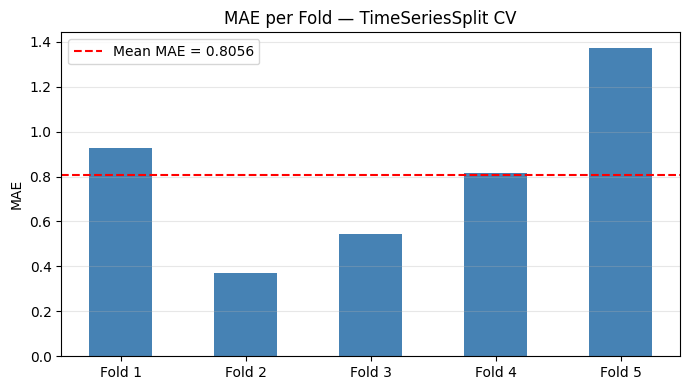

In [161]:
# ── 9.5  CV MAE per Fold ──────────────────────
plt.figure(figsize=(7, 4))
folds = [f"Fold {i+1}" for i in range(len(cv_mae))]
plt.bar(folds, -cv_mae, color="steelblue", width=0.5)
plt.axhline(-cv_mae.mean(), color="red", linestyle="--",
            label=f"Mean MAE = {-cv_mae.mean():.4f}")
plt.title("MAE per Fold — TimeSeriesSplit CV")
plt.ylabel("MAE")
plt.legend()
plt.grid(True, alpha=0.3, axis="y")
plt.tight_layout()
plt.savefig("07_cv_mae_per_fold.png", dpi=150)
plt.show()

### Ringkasan Hasil :


In [162]:
print("\n" + "="*55)
print("  RINGKASAN AKHIR")
print("="*55)
print(f"  Fitur digunakan       : {len(FEATURE_COLS)}")
print(f"  Data train            : {len(X_train)} baris")
print(f"  Data test             : {len(X_test)} baris")
print(f"\n  [TRAIN]")
print(f"    MAE   = {mae_tr:.4f}")
print(f"    RMSE  = {rmse_tr:.4f}")
print(f"    R²    = {r2_tr:.4f}")
print(f"    MAPE  = {mape_tr:.2f}%")
print(f"\n  [TEST]")
print(f"    MAE   = {mae_te:.4f}")
print(f"    RMSE  = {rmse_te:.4f}")
print(f"    R²    = {r2_te:.4f}")
print(f"    MAPE  = {mape_te:.2f}%")
print(f"\n  [CV — TimeSeriesSplit k=5 pada Train]")
print(f"    MAE   = {-cv_mae.mean():.4f} ± {cv_mae.std():.4f}")
print(f"    RMSE  = {-cv_rmse.mean():.4f} ± {cv_rmse.std():.4f}")
print(f"    R²    = {cv_r2.mean():.4f}  ± {cv_r2.std():.4f}")
print("="*55)


  RINGKASAN AKHIR
  Fitur digunakan       : 22
  Data train            : 1392 baris
  Data test             : 349 baris

  [TRAIN]
    MAE   = 0.5853
    RMSE  = 0.9783
    R²    = 0.9967
    MAPE  = 1.29%

  [TEST]
    MAE   = 2.0998
    RMSE  = 2.7431
    R²    = 0.9703
    MAPE  = 1.59%

  [CV — TimeSeriesSplit k=5 pada Train]
    MAE   = 0.8056 ± 0.3449
    RMSE  = 1.1014 ± 0.5427
    R²    = 0.9029  ± 0.1358


### Prediksi :

### Prediksi 1 hari kedepan :

In [163]:
last_row_features = df_model[FEATURE_COLS].iloc[[-1]].values
last_row_scaled   = scaler.transform(last_row_features)
next_day_pred     = model.predict(last_row_scaled)[0]
last_actual_date  = df_model["Date"].iloc[-1]

print(f"\n  Prediksi harga closing setelah {last_actual_date.date()}:")
print(f"  → USD {next_day_pred:.4f}")
print("="*55)


  Prediksi harga closing setelah 2021-12-28:
  → USD 179.6445
